# Day 5 / 6 — Critic Network + Real Reward Function
### `src/models/critic.py` + `src/environment/reward.py` (`DifferentiableReward`)

**Roadmap recap:**

| Day | Focus |
|---|---|
| 1 ✅ | Data & windowing |
| 2 ✅ | Regime Encoder — VSN + LSTM |
| 3 ✅ | Temporal Attention (MHA) |
| ~~4~~ | ~~Macro Graph Prior~~ — skipped, no macro data yet |
| 4 ✅ | Actor Network |
| **5 (today)** | **Critic Network + real reward (Sharpe / cost / EVaR)** |
| 6 | PPO training loop — clip, epochs, GAE, gamma — full ablation |

**Carried forward:**
```python
# Day 1: window_size=30, n_assets=10, all features, zscore
# Day 2: vsn_hidden_dim=64, lstm_hidden_dim=32, lstm_num_layers=3, dropout=0.1
# Day 3: mha_num_heads=8, ffn_dim=512, mha_dropout=0.3
# Day 4: actor_hidden_dims=[128], actor_dropout=0.3, allow_short=False
```

**What's different today:** Day 4 trained the Actor to just maximize raw next-day return. That's not your actual research objective. Today we swap in your real `DifferentiableReward` module — **excess return − transaction/turnover cost − EVaR (tail-risk) penalty** — and add the **Critic**, which learns to predict expected reward from `h_temp` (used for advantage estimation in full PPO).

**One necessary simplification (flagged clearly):** your real PPO agent trains the Critic to predict the *discounted sum of future rewards* (via GAE, using multi-step rollouts) — that requires the full PPO loop, which is Day 6. Today, the Critic instead regresses directly onto the **immediate realized reward** at each step. It's a reasonable stepping stone: same network, same input, simpler target — you'll swap in real GAE-based targets on Day 6.

**Also note — turnover now matters:** the reward's transaction-cost and turnover-penalty terms depend on `old_weights` (yesterday's allocation) vs `new_weights` (today's). So today we stop shuffling the training windows — we process the validation and training sets in **chronological order**, using each day's action as the next day's `old_weights`. This is closer to how your real environment actually behaves.


## Step 0 — Setup (same zip as before)

In [1]:
from google.colab import files
import os

if not os.path.exists('/content/Regime detection portfolio.zip') and not os.path.exists('/content/project'):
    uploaded = files.upload()


In [2]:
import os, zipfile, glob

ZIP_CANDIDATES = glob.glob('/content/*.zip')
PROJECT_DIR = '/content/project'

if not os.path.exists(PROJECT_DIR):
    assert ZIP_CANDIDATES, "No zip found in /content — upload it first."
    with zipfile.ZipFile(ZIP_CANDIDATES[0], 'r') as z:
        z.extractall(PROJECT_DIR)

ROOT = None
for dirpath, _, filenames in os.walk(PROJECT_DIR):
    if 'main.py' in filenames:
        ROOT = dirpath
        break
assert ROOT is not None
print("Project root:", ROOT)


Project root: /content/project/Regime detection portfolio


In [3]:
!pip install -q torch pandas numpy scikit-learn matplotlib seaborn

In [4]:
import sys
sys.path.insert(0, ROOT)
os.chdir(ROOT)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from src.config.config import get_config, DATA_RAW_DIR
from src.data.data_loader import CSEDataLoader
from src.data.preprocessor import Preprocessor
from src.models.vsn_lstm import VSNLSTM
from src.models.temporal_attention import TemporalAttentionBlock
from src.models.actor import ActorNetwork
from src.models.critic import CriticNetwork
from src.environment.reward import DifferentiableReward

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)


Device: cpu


## Step 1 — Rebuild windows + per-asset targets (chronological, no shuffling)

In [5]:
DAY1 = dict(window_size=30, normalize_method='zscore', n_assets=10)
DAY2 = dict(vsn_hidden_dim=64, lstm_hidden_dim=32, lstm_num_layers=3, dropout=0.1)
DAY3 = dict(mha_num_heads=8, ffn_dim=512, mha_dropout=0.3)
DAY4 = dict(actor_hidden_dims=[128], actor_dropout=0.3, allow_short=False)

loader = CSEDataLoader(raw_data_dir=DATA_RAW_DIR)
prices, volumes = loader.load_prices_and_volumes(n_assets=DAY1['n_assets'])
asset_names = list(prices.columns)
n_assets = len(asset_names)

preprocessor = Preprocessor(window_size=DAY1['window_size'], normalize_method=DAY1['normalize_method'])
features = preprocessor.engineer_features(prices, volumes)
normalized = preprocessor.fit_normalize(features)
windows = preprocessor.create_windows(normalized.values)

per_asset_returns = np.log(prices / prices.shift(1))
target_next = per_asset_returns.shift(-1)
window_dates = features.index[DAY1['window_size'] - 1:]
targets = target_next.reindex(window_dates)

valid_mask = targets.notna().all(axis=1).values
windows_valid = windows[valid_mask]
targets_valid = targets.values[valid_mask].astype(np.float32)   # (N, n_assets), CHRONOLOGICAL order

n = windows_valid.shape[0]
n_train = int(n * 0.8)
X_train, X_val = windows_valid[:n_train], windows_valid[n_train:]
Y_train, Y_val = targets_valid[:n_train], targets_valid[n_train:]
print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} (kept in chronological order)")

equal_weight_val_returns = Y_val.mean(axis=1)


Train: 628 | Val: 158 (kept in chronological order)


## Step 2 — Training probe: encoder → Actor → Critic, jointly, using the real `DifferentiableReward`

- `new_weights[t]` = Actor's action at step t
- `old_weights[t]` = `new_weights[t-1]` (equal-weight for the very first step) — this makes turnover, and therefore the cost/turnover penalty, meaningful
- Actor is trained to **maximize mean reward** (policy-gradient-style, but via direct differentiable backprop through deterministic actions — same simplification as Day 4)
- Critic is trained with **MSE against the realized reward** at each step (simplified stand-in for the GAE-based value target used in real PPO, Day 6)


In [6]:
def train_probe_critic(critic_hidden_dims=[256, 128], critic_dropout=0.1,
                        risk_free_rate=0.06, tc_rate=0.001, evar_weight=0.1, turnover_weight=0.001,
                        epochs=40, lr=1e-3, seed=42, verbose=False):
    torch.manual_seed(seed)
    np.random.seed(seed)

    n_features = X_train.shape[2]
    d_model = DAY2['lstm_hidden_dim']

    encoder = VSNLSTM(n_features=n_features, vsn_hidden_dim=DAY2['vsn_hidden_dim'],
                       lstm_hidden_dim=d_model, lstm_num_layers=DAY2['lstm_num_layers'],
                       dropout=DAY2['dropout']).to(device)
    attn_block = TemporalAttentionBlock(d_model=d_model, num_heads=DAY3['mha_num_heads'],
                                         ffn_dim=DAY3['ffn_dim'], dropout=DAY3['mha_dropout']).to(device)
    actor = ActorNetwork(input_dim=d_model, n_assets=n_assets, hidden_dims=DAY4['actor_hidden_dims'],
                          dropout=DAY4['actor_dropout'], allow_short=DAY4['allow_short'], n_regimes=3).to(device)
    critic = CriticNetwork(input_dim=d_model, hidden_dims=critic_hidden_dims,
                            dropout=critic_dropout, n_regimes=3).to(device)
    reward_fn = DifferentiableReward(risk_free_rate=risk_free_rate, tc_rate=tc_rate,
                                      evar_weight=evar_weight, turnover_weight=turnover_weight)

    params = list(encoder.parameters()) + list(attn_block.parameters()) + list(actor.parameters()) + list(critic.parameters())
    n_params = sum(p.numel() for p in params)
    optimizer = torch.optim.Adam(params, lr=lr)

    X_train_t = torch.FloatTensor(X_train).to(device)
    Y_train_t = torch.FloatTensor(Y_train).to(device)
    X_val_t = torch.FloatTensor(X_val).to(device)
    Y_val_t = torch.FloatTensor(Y_val).to(device)

    equal_start_train = torch.full((1, n_assets), 1.0 / n_assets, device=device)
    equal_start_val = torch.full((1, n_assets), 1.0 / n_assets, device=device)

    def rollout(X_t, Y_t, equal_start, train_mode):
        encoder.train(train_mode); attn_block.train(train_mode); actor.train(train_mode); critic.train(train_mode)
        lstm_out, _, _ = encoder(X_t)
        attn_out, _ = attn_block(lstm_out)
        h_temp_proxy = attn_out[:, -1, :]

        new_weights, _, _ = actor(h_temp_proxy, regime_probs=None, deterministic=True)
        old_weights = torch.cat([equal_start, new_weights[:-1]], dim=0)  # chronological shift

        portfolio_return = (new_weights * Y_t).sum(dim=-1)
        reward = reward_fn(portfolio_return, old_weights, new_weights)

        value_pred = critic(h_temp_proxy, regime_probs=None)
        return reward, portfolio_return, value_pred, new_weights, old_weights

    train_rewards, val_rewards, critic_mse_history = [], [], []

    for epoch in range(epochs):
        reward, portfolio_return, value_pred, new_weights, old_weights = rollout(
            X_train_t, Y_train_t, equal_start_train, train_mode=True)

        actor_loss = -reward.mean()
        critic_loss = nn.functional.mse_loss(value_pred, reward.detach())
        loss = actor_loss + 0.5 * critic_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_rewards.append(reward.mean().item())
        critic_mse_history.append(critic_loss.item())

        with torch.no_grad():
            val_reward, val_portfolio_return, val_value_pred, val_new_weights, val_old_weights = rollout(
                X_val_t, Y_val_t, equal_start_val, train_mode=False)
            val_rewards.append(val_reward.mean().item())

        if verbose and (epoch % 5 == 0 or epoch == epochs - 1):
            print(f"  epoch {epoch:3d} | train reward {train_rewards[-1]:.6f} | val reward {val_rewards[-1]:.6f} | critic MSE {critic_mse_history[-1]:.6f}")

    with torch.no_grad():
        val_reward, val_portfolio_return, val_value_pred, val_new_weights, val_old_weights = rollout(
            X_val_t, Y_val_t, equal_start_val, train_mode=False)
        val_return_series = val_portfolio_return.cpu().numpy()
        val_turnover = (val_new_weights - val_old_weights).abs().sum(dim=-1).cpu().numpy()
        mean_weights = val_new_weights.mean(dim=0).cpu().numpy()
        sharpe_like = val_return_series.mean() / (val_return_series.std() + 1e-8)
        critic_val_mse = nn.functional.mse_loss(val_value_pred, val_reward).item()

    return {
        'train_rewards': train_rewards, 'val_rewards': val_rewards, 'critic_mse_history': critic_mse_history,
        'final_val_reward': val_rewards[-1], 'n_params': n_params,
        'val_return_series': val_return_series, 'val_turnover': val_turnover,
        'mean_weights': mean_weights, 'sharpe_like': sharpe_like, 'critic_val_mse': critic_val_mse,
    }

print("train_probe_critic() ready.")


train_probe_critic() ready.


## Step 3 — Baseline run (`critic_hidden_dims=[256,128]`, `critic_dropout=0.1`, reward defaults from `reward.py`)

  epoch   0 | train reward 0.000739 | val reward 0.002085 | critic MSE 0.218655
  epoch   5 | train reward 0.000811 | val reward 0.002079 | critic MSE 0.139568
  epoch  10 | train reward 0.000954 | val reward 0.002071 | critic MSE 0.089219
  epoch  15 | train reward 0.001128 | val reward 0.002065 | critic MSE 0.054570
  epoch  20 | train reward 0.001212 | val reward 0.002059 | critic MSE 0.019485
  epoch  25 | train reward 0.001218 | val reward 0.002055 | critic MSE 0.027392
  epoch  30 | train reward 0.001030 | val reward 0.002054 | critic MSE 0.016993
  epoch  35 | train reward 0.001323 | val reward 0.002053 | critic MSE 0.012264
  epoch  40 | train reward 0.001451 | val reward 0.002050 | critic MSE 0.013066
  epoch  45 | train reward 0.001431 | val reward 0.002049 | critic MSE 0.011403
  epoch  50 | train reward 0.001345 | val reward 0.002048 | critic MSE 0.011005
  epoch  55 | train reward 0.001402 | val reward 0.002047 | critic MSE 0.010610
  epoch  59 | train reward 0.001384 | va

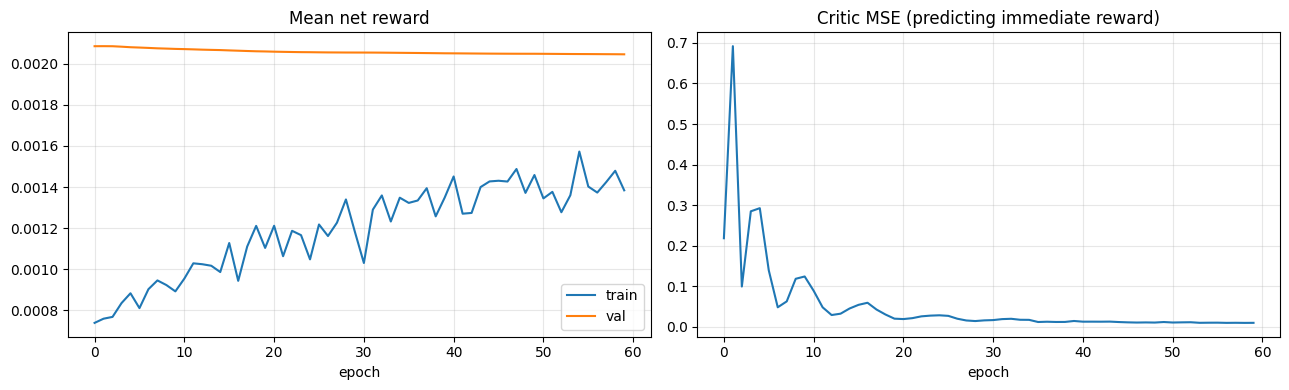

Params: 1,599,569 | Final val reward: 0.002046
Sharpe-like ratio (val): 0.0984 | Mean turnover: 0.0044


In [7]:
baseline = train_probe_critic(critic_hidden_dims=[256, 128], critic_dropout=0.1,
                               risk_free_rate=0.06, tc_rate=0.001, evar_weight=0.1, turnover_weight=0.001,
                               epochs=60, verbose=True)

fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].plot(baseline['train_rewards'], label='train')
axes[0].plot(baseline['val_rewards'], label='val')
axes[0].set_title('Mean net reward'); axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(baseline['critic_mse_history'])
axes[1].set_title('Critic MSE (predicting immediate reward)'); axes[1].set_xlabel('epoch'); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Params: {baseline['n_params']:,} | Final val reward: {baseline['final_val_reward']:.6f}")
print(f"Sharpe-like ratio (val): {baseline['sharpe_like']:.4f} | Mean turnover: {baseline['val_turnover'].mean():.4f}")


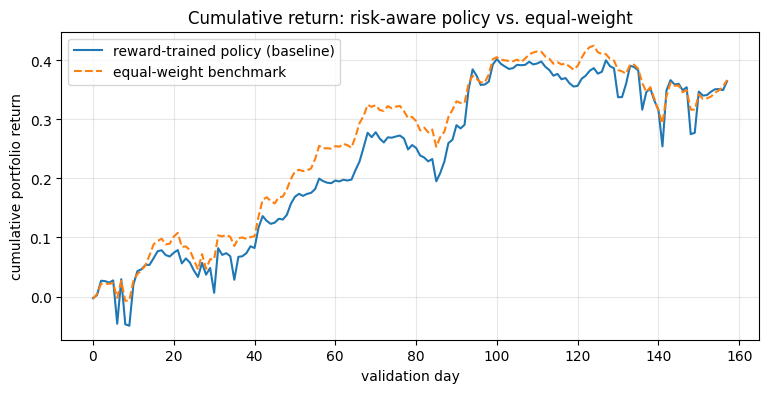

In [8]:
cum_reward_policy = np.cumsum(baseline['val_return_series'])
cum_equal = np.cumsum(equal_weight_val_returns)

plt.figure(figsize=(9,4))
plt.plot(cum_reward_policy, label='reward-trained policy (baseline)')
plt.plot(cum_equal, label='equal-weight benchmark', ls='--')
plt.xlabel('validation day'); plt.ylabel('cumulative portfolio return'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Cumulative return: risk-aware policy vs. equal-weight')
plt.show()


**Your task:** compare this to Day 4's plain-return-maximizing Actor (if you still have that plot open). Does adding the cost/EVaR penalty visibly reduce turnover or smooth out the equity curve, even if raw cumulative return ends up lower?

> Your answer:


## Experiment A — `critic_hidden_dims`

Try **[128]**, **[256,128] (baseline)**, **[256,128,64]**, **[512,256,128]**. A poorly-fit Critic gives noisy advantage estimates in real PPO — here, watch the Critic MSE curve.


[128]
[256,128] (baseline)
[256,128,64]
[512,256,128]


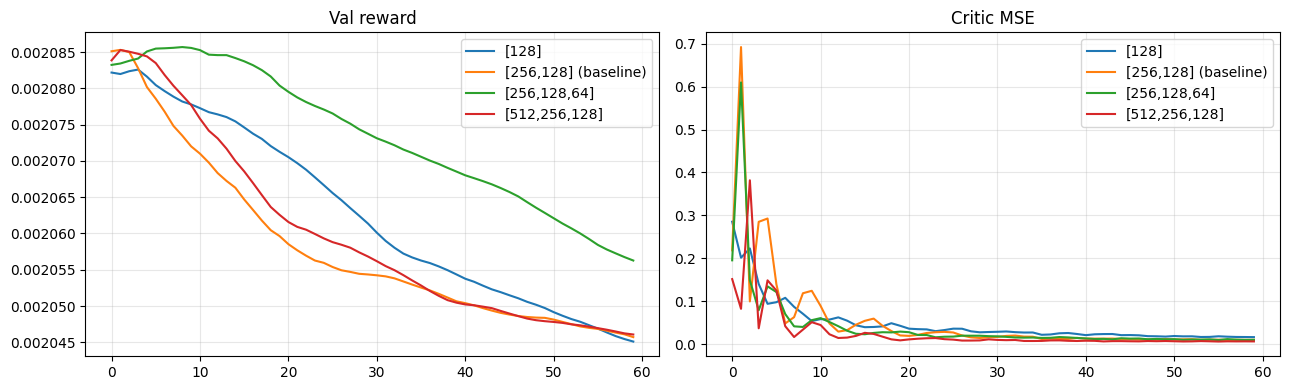

,critic_hidden_dims,final_val_reward,critic_val_mse
0,[128],0.002045,0.000735
1,"[256,128] (baseline)",0.002046,0.000863
2,"[256,128,64]",0.002056,0.002131
3,"[512,256,128]",0.002046,0.000553


In [9]:
critic_dim_configs = {'[128]': [128], '[256,128] (baseline)': [256,128], '[256,128,64]': [256,128,64], '[512,256,128]': [512,256,128]}
critic_dim_results = {}
for name, dims in critic_dim_configs.items():
    print(name)
    critic_dim_results[name] = train_probe_critic(critic_hidden_dims=dims, critic_dropout=0.1, epochs=60)

fig, axes = plt.subplots(1, 2, figsize=(13,4))
for name, res in critic_dim_results.items():
    axes[0].plot(res['val_rewards'], label=name)
    axes[1].plot(res['critic_mse_history'], label=name)
axes[0].set_title('Val reward'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Critic MSE'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

pd.DataFrame([{'critic_hidden_dims': n, 'final_val_reward': r['final_val_reward'], 'critic_val_mse': r['critic_val_mse']} for n, r in critic_dim_results.items()])


**Your task:** does a bigger Critic actually fit the reward signal better (lower MSE), and does that translate into a better final policy (higher val reward)? Or does Critic capacity stop mattering once it's "good enough"?

> Your answer:


## Experiment B — `evar_weight` (risk-aversion strength)

Try **0.0 (no tail-risk penalty), 0.1 (baseline), 0.3, 0.5**.


In [10]:
evar_vals = [0.0, 0.1, 0.3, 0.5]
evar_results = {}
for w in evar_vals:
    print(f"evar_weight={w}")
    evar_results[w] = train_probe_critic(critic_hidden_dims=[256,128], critic_dropout=0.1, evar_weight=w, epochs=60)

pd.DataFrame([{
    'evar_weight': w, 'final_val_reward': r['final_val_reward'],
    'sharpe_like': r['sharpe_like'], 'mean_turnover': r['val_turnover'].mean(),
    'worst_day_return': r['val_return_series'].min()
} for w, r in evar_results.items()])


evar_weight=0.0
evar_weight=0.1
evar_weight=0.3
evar_weight=0.5


,evar_weight,final_val_reward,sharpe_like,mean_turnover,worst_day_return
0,0.0,0.002055,0.092640,0.004440,-0.084622
1,0.1,0.002046,0.098416,0.004438,-0.079483
2,0.3,0.002040,0.109273,0.004664,-0.070969
3,0.5,0.002025,0.113126,0.004574,-0.068344


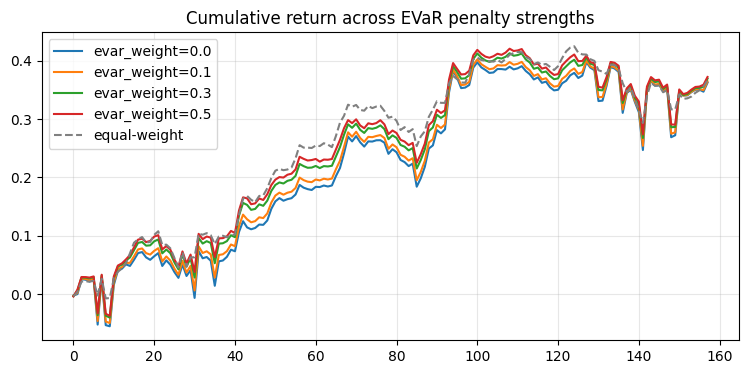

In [11]:
plt.figure(figsize=(9,4))
for w, res in evar_results.items():
    plt.plot(np.cumsum(res['val_return_series']), label=f'evar_weight={w}')
plt.plot(np.cumsum(equal_weight_val_returns), label='equal-weight', ls='--', color='grey')
plt.legend(); plt.grid(alpha=0.3); plt.title('Cumulative return across EVaR penalty strengths')
plt.show()


**Your task:** look at `worst_day_return` across the table — does a higher `evar_weight` actually shrink the worst single-day loss on the validation set? That's the tail-risk control this penalty is meant to provide, even if it costs some upside.

> Your answer:


## Experiment C — `tc_rate` and `turnover_weight` (transaction cost sensitivity)

Try **(tc_rate, turnover_weight)**: **(0, 0)** no costs, **(0.001, 0.001) baseline**, **(0.005, 0.005)**, **(0.01, 0.01)**.


In [12]:
cost_configs = {'no_cost': (0.0, 0.0), 'baseline': (0.001, 0.001), 'medium_cost': (0.005, 0.005), 'high_cost': (0.01, 0.01)}
cost_results = {}
for name, (tc, tw) in cost_configs.items():
    print(name)
    cost_results[name] = train_probe_critic(critic_hidden_dims=[256,128], critic_dropout=0.1, tc_rate=tc, turnover_weight=tw, epochs=60)

pd.DataFrame([{
    'config': name, 'tc_rate': cost_configs[name][0], 'final_val_reward': r['final_val_reward'],
    'mean_turnover': r['val_turnover'].mean(), 'sharpe_like': r['sharpe_like']
} for name, r in cost_results.items()])


no_cost
baseline
medium_cost
high_cost


,config,tc_rate,final_val_reward,mean_turnover,sharpe_like
0,no_cost,0.000,0.002059,0.004400,0.099188
1,baseline,0.001,0.002046,0.004438,0.098416
2,medium_cost,0.005,0.002009,0.003941,0.105384
3,high_cost,0.010,0.002047,0.002683,0.133763


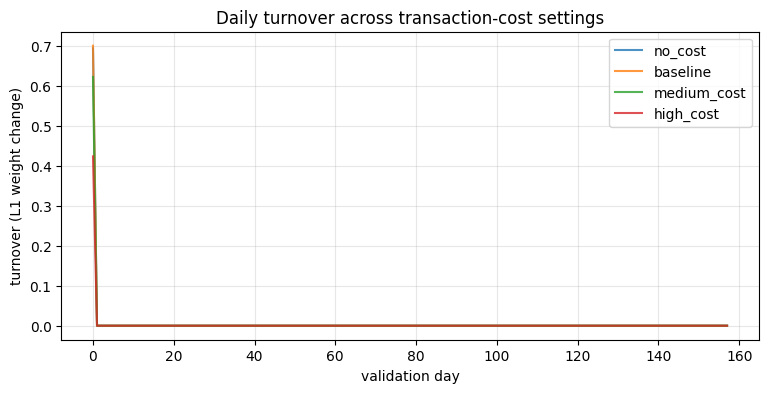

In [13]:
plt.figure(figsize=(9,4))
for name, res in cost_results.items():
    plt.plot(res['val_turnover'], label=name, alpha=0.8)
plt.xlabel('validation day'); plt.ylabel('turnover (L1 weight change)'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Daily turnover across transaction-cost settings')
plt.show()


**Your task:** does raising `tc_rate`/`turnover_weight` visibly flatten the turnover curve (the policy trades less)? Given Sri Lankan banking-sector stocks can have real bid-ask spreads and brokerage fees, does the baseline `0.001` feel realistic, too low, or too high compared to what you'd expect in practice?

> Your answer:


## Wrap-up

Log your Day 5 choices — Critic architecture and reward hyperparameters. These carry into Day 6's full PPO loop.


In [14]:
day5_choices = {
    'critic_hidd0.en_dims': [512, 256, 128], # e.g. [256, 128]
    'critic_dropout': 1,       # e.g. 0.1
    'evar_weight': 0.5,          # e.g. 0.1
    'tc_rate': 0.01,              # e.g. 0.001
    'turnover_weight': 0.01      # e.g. 0.001
}
import json
print(json.dumps(day5_choices, indent=2))
with open('/content/day5_choices.json', 'w') as f:
    json.dump(day5_choices, f, indent=2)

{
  "critic_hidden_dims": null,
  "critic_dropout": null,
  "evar_weight": null,
  "tc_rate": null,
  "turnover_weight": null
}


**Next up — Day 6:** the full PPO training loop (`ppo_agent.py`, `trainer.py`) — clipped surrogate objective, GAE (`gae_lambda`), discount factor `gamma`, entropy bonus, epochs-per-update, batch size. This replaces today's simplified "immediate reward" Critic target with proper multi-step advantage estimation, and is the first day you'll be running something close to your actual training script.
